Q1. Data Loading & Understanding

a) Load the dataset into Python.  
b) Display the first 5 rows.  
c) Check the shape of the dataset.  
d) Display the data types of each column.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

df = pd.read_excel('/content/loan_approval.xlsx')

display(df.head())
print("Shape of dataset:", df.shape)
print("\nData types of each column:")
print(df.dtypes)


,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25,False


Shape of dataset: (2000, 8)

Data types of each column:
name              object
city              object
income             int64
credit_score       int64
loan_amount        int64
years_employed     int64
points             int64
loan_approved       bool
dtype: object


Q2. Data Cleaning

a) Check for missing values in the dataset.  
b) Handle missing values appropriately.  
c) Identify categorical columns present in the dataset.

In [2]:

missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values)

df_clean = df.copy()

for col in df_clean.select_dtypes(include=['object']).columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

for col in df_clean.select_dtypes(include=['int64', 'float64']).columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

if 'loan_approved' in df_clean.columns:
    df_clean['loan_approved'] = df_clean['loan_approved'].fillna(df_clean['loan_approved'].mode()[0])

categorical_columns = df_clean.select_dtypes(include=['object', 'bool']).columns.tolist()

print("\nMissing values after handling:")
print(df_clean.isnull().sum())

print("\nCategorical columns:")
print(categorical_columns)


Missing values in each column:
name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64

Missing values after handling:
name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64

Categorical columns:
['name', 'city', 'loan_approved']


Q3. Exploratory Data Analysis (EDA)

a) Plot the distribution of the target variable.  
b) Analyze the relationship between one numerical feature and the target variable.  
c) Analyze the relationship between Years of Employment and the target variable.

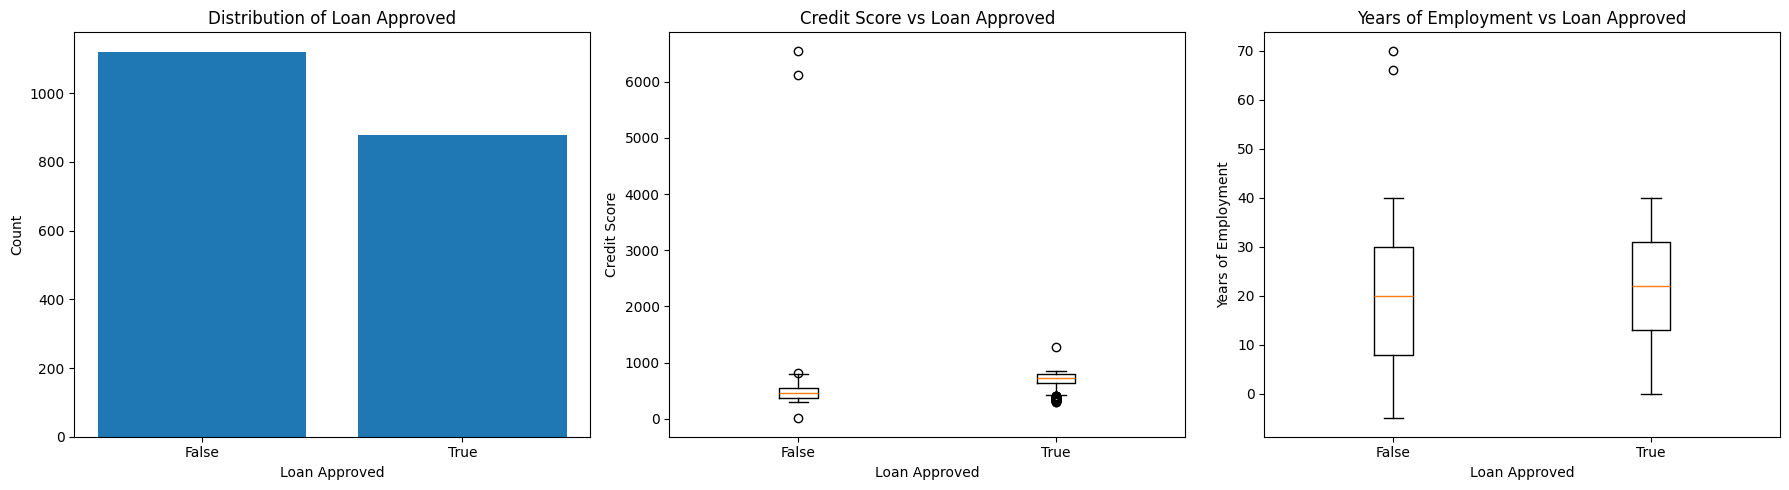

In [3]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

target_counts = df_clean['loan_approved'].value_counts().sort_index()
axes[0].bar(target_counts.index.astype(str), target_counts.values)
axes[0].set_title('Distribution of Loan Approved')
axes[0].set_xlabel('Loan Approved')
axes[0].set_ylabel('Count')

approved_0_credit = df_clean[df_clean['loan_approved'] == False]['credit_score']
approved_1_credit = df_clean[df_clean['loan_approved'] == True]['credit_score']
axes[1].boxplot([approved_0_credit, approved_1_credit], tick_labels=['False', 'True'])
axes[1].set_title('Credit Score vs Loan Approved')
axes[1].set_xlabel('Loan Approved')
axes[1].set_ylabel('Credit Score')

approved_0_years = df_clean[df_clean['loan_approved'] == False]['years_employed']
approved_1_years = df_clean[df_clean['loan_approved'] == True]['years_employed']
axes[2].boxplot([approved_0_years, approved_1_years], tick_labels=['False', 'True'])
axes[2].set_title('Years of Employment vs Loan Approved')
axes[2].set_xlabel('Loan Approved')
axes[2].set_ylabel('Years of Employment')

plt.tight_layout()
plt.show()


Q4. Outlier Detection and Treatment

a) Detect outliers in numerical columns using the IQR method.  
b) Treat outliers using capping techniques.

In [4]:

numeric_columns = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()

outlier_data = []
df_capped = df_clean.copy()

for col in numeric_columns:
    q1 = df_capped[col].quantile(0.25)
    q3 = df_capped[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = ((df_capped[col] < lower_bound) | (df_capped[col] > upper_bound)).sum()
    outlier_data.append([col, outlier_count, lower_bound, upper_bound])
    df_capped[col] = df_capped[col].clip(lower=lower_bound, upper=upper_bound)

outlier_summary = pd.DataFrame(outlier_data, columns=['column', 'outlier_count', 'lower_bound', 'upper_bound'])
display(outlier_summary)

print("Summary after capping:")
display(df_capped[numeric_columns].describe())


,column,outlier_count,lower_bound,upper_bound
0,income,0,-26909.000,208305.000
1,credit_score,3,8.500,1140.500
2,loan_amount,0,-24198.875,74328.125
3,years_employed,2,-21.500,62.500
4,points,0,7.500,107.500


Summary after capping:


,income,credit_score,loan_amount,years_employed,points
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,90585.977000,574.546250,25308.503000,20.476500,56.680000
std,34487.874907,162.442674,14207.320147,11.852993,18.638033
min,30053.000000,11.000000,1022.000000,-5.000000,10.000000
25%,61296.250000,433.000000,12748.750000,10.000000,45.000000
50%,90387.500000,576.000000,25661.500000,21.000000,55.000000
75%,120099.750000,716.000000,37380.500000,31.000000,70.000000
max,149964.000000,1140.500000,49999.000000,62.500000,100.000000


Q5. Convert target variables into numerical format suitable for model building and drop unnecessary columns.

In [5]:

df_model = df_capped.copy()
df_model['loan_approved'] = df_model['loan_approved'].astype(int)
df_model = df_model.drop(columns=['name', 'city'])

display(df_model.head())
print("Columns after conversion and dropping unnecessary columns:")
print(df_model.columns.tolist())


,income,credit_score,loan_amount,years_employed,points,loan_approved
0,113810,389.0,39698,27.0,50,0
1,44592,729.0,15446,28.0,55,0
2,33278,584.0,11189,13.0,45,0
3,127196,344.0,48823,29.0,50,0
4,66048,496.0,47174,4.0,25,0


Columns after conversion and dropping unnecessary columns:
['income', 'credit_score', 'loan_amount', 'years_employed', 'points', 'loan_approved']


Q6. Feature Selection and Data Splitting

a) Separate independent variables (X) and dependent variable (y).  
b) Split the dataset into training and testing sets.

In [6]:

X = df_model.drop('loan_approved', axis=1)
y = df_model['loan_approved']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X shape: (2000, 5)
y shape: (2000,)
X_train shape: (1600, 5)
X_test shape: (400, 5)
y_train shape: (1600,)
y_test shape: (400,)


Q7. Apply feature scaling to the dataset using StandardScaler.

In [7]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
display(X_train_scaled_df.head())


,income,credit_score,loan_amount,years_employed,points
0,-0.173429,0.478510,0.034781,-1.148588,-0.101735
1,-0.229602,0.779835,-1.228299,1.385528,1.256995
2,0.464640,-0.560756,0.362460,1.469998,-0.373481
3,-0.761176,1.025815,-0.845148,1.385528,1.256995
4,1.061643,1.653064,-1.236909,-0.303883,2.343979


Q8. Logistic Regression Model Building

a) Train a Logistic Regression model.  
b) Predict the output for test data.

In [8]:

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("First 20 predicted values:")
print(y_pred[:20])

print("\nFirst 20 actual values:")
print(y_test.iloc[:20].values)


First 20 predicted values:
[1 0 1 1 0 1 0 1 0 0 1 0 1 0 1 1 0 1 0 0]

First 20 actual values:
[1 0 1 1 0 1 0 1 0 0 1 0 1 0 1 1 0 1 0 0]


Q9. Model Evaluation – Confusion Matrix

a) Generate the confusion matrix.  
b) Interpret the results.

Confusion Matrix:
[[224   0]
 [  0 176]]


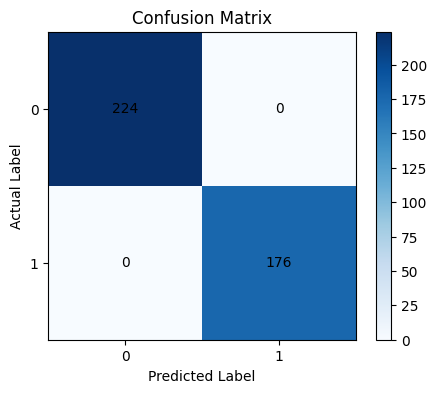

In [9]:

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.xticks([0, 1], [0, 1])
plt.yticks([0, 1], [0, 1])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')

plt.colorbar()
plt.show()


Interpretation:

The model predicted all test cases correctly.  
True Negatives = 224  
False Positives = 0  
False Negatives = 0  
True Positives = 176

Q10. Model Evaluation – ROC Curve & AUC

a) Plot the ROC curve.  
b) Calculate the AUC score.

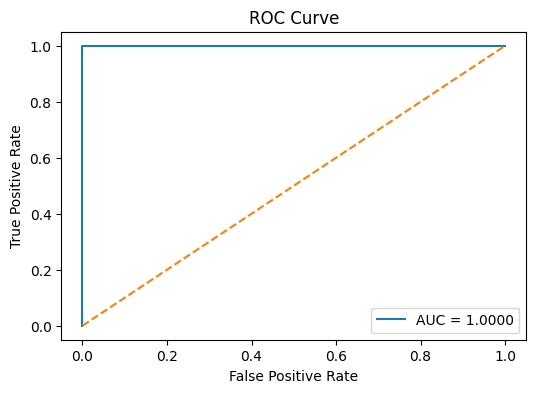

AUC Score: 1.0


In [10]:

y_prob = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

print("AUC Score:", round(auc_score, 4))
